# PyTorch from Scratch — Tutorial

> **Goal:** Understand tensors deeply — scalars, vectors, matrices, shape quirks, and how to build your first model.

---

### How to use this beginner version

- Every executable line has a plain-language comment immediately above it explaining **what the line does and why it is there**.
- After every code cell, a **“What we learnt from this cell”** section interprets the output and connects it to the underlying concept.
- Some cells use random numbers or randomly initialised models, so exact numerical values can change when you rerun the notebook. Focus on the shapes, trends, and concepts highlighted in the explanation.

---
## 🔎 PDF Instructor Guide — Ctrl+F Cell Navigation

The notebook code cells below are marked to match the **cell indices used in the instructor PDF**.
To jump directly to a code block, press **Ctrl+F** (or **Cmd+F** on Mac) and search the exact marker, for example:

```text
PDF CELL <number>:
```

That takes you directly to the **training loop** block referenced as cell index 54 in the PDF.

| PDF cell | Slide | Notebook block |
|---:|---:|---|
| 1 | Slide 1 | Setup / Imports |
| 4 | Slide 3 | Sklearn Vs Pytorch |
| 7 | Slide 5 | Scalar Basics |
| 9 | Slide 5 | Scalar Mse Loss |
| 12 | Slide 6 | Vector Creation / Indexing |
| 14 | Slide 6 | Vector Operations / Dot Product |
| 17 | Slide 7 | Matrix Shape / Indexing |
| 19 | Slide 7 | Matrix Ops / Matmul / Reductions |
| 22 | Slide 8 | 3D Tensor |
| 24 | Slide 9 | 4D Image Tensor |
| 27 | Slide 10 | Shape Forms [5], [5,1], [1,5] |
| 29 | Slide 11 | Matmul Shape Behaviour |
| 31 | Slide 11 | Sklearn Target Shape Fix |
| 34 | Slide 13 | View / Reshape |
| 36 | Slide 14 | Squeeze / Unsqueeze |
| 38 | Slide 14 | Broadcasting |
| 41 | Slide 15 | Dtype |
| 43 | Slide 16 | Device Cpu / Gpu |
| 45 | Slide 17 | Autograd |
| 48 | Slide 18 | Regression Data Prep |
| 50 | Slide 18 | Sklearn Baseline |
| 52 | Slide 19 | Pytorch Model Setup |
| 54 | Slide 20 | Training Loop |
| 56 | Slide 21 | Evaluation / Plots |
| 58 | Slide 22 | Deeper Model |


In [1]:
# ================================================================
# PDF CELL 1: SETUP / IMPORTS
# Instructor PDF reference: Slide 1. Search the line above to jump here.
# ================================================================
# This first cell prepares the libraries that we will use throughout the notebook.
# `import torch` loads the main PyTorch package, which provides tensors, mathematical operations, automatic differentiation, and GPU support.
import torch
# `torch.nn` contains neural-network building blocks such as layers, activation functions, and loss functions; we give it the short name `nn`.
import torch.nn as nn
# NumPy is a widely used numerical-computing library; we use it here to compare NumPy arrays with PyTorch tensors.
import numpy as np

# `torch.__version__` tells us exactly which PyTorch version is running, which is useful when reproducing code or debugging version-specific behaviour.
print(f"PyTorch version : {torch.__version__}")
# `torch.cuda.is_available()` returns True when PyTorch can access a CUDA-compatible GPU in the current environment, otherwise it returns False.
print(f"CUDA available  : {torch.cuda.is_available()}")
# This print statement adds a blank line first (`\n`) and then confirms that the setup cell finished successfully.
print("\n✅ Setup complete — let's go!")


PyTorch version : 2.11.0+cu130
CUDA available  : True

✅ Setup complete — let's go!


### ✅ What we learnt from this cell

- PyTorch and NumPy imported successfully, so the environment is ready for the rest of the tutorial.
- The output reports the exact PyTorch version being used. This matters because APIs and hardware support can differ between versions.
- `CUDA available: True` in the saved run means that this notebook session could see a CUDA-capable GPU. On another computer this may print `False`, and the tutorial can still run on the CPU.

---
## Section 1 — Why move from sklearn to PyTorch? 🤔

sklearn is fantastic for classical ML. But it has hard limits:

| Limitation | sklearn | PyTorch |
|---|---|---|
| **GPU acceleration** | ❌ CPU only | ✅ Native CUDA support |
| **Custom architectures** | ❌ Fixed models | ✅ Build anything |
| **Automatic gradients** | ❌ Not available | ✅ Autograd built-in |
| **Large-scale training** | ❌ Data must fit in RAM | ✅ Minibatch streaming |
| **Deep learning** | ⚠️ Very limited | ✅ First-class support |

**Rule of thumb:**
- 📊 Tabular data, quick baselines → use **sklearn**
- 🧠 Deep learning, custom models, GPU needed → use **PyTorch**

In [2]:
# ================================================================
# PDF CELL 4: SKLEARN VS PYTORCH
# Instructor PDF reference: Slide 3. Search the line above to jump here.
# ================================================================
# This cell gives a small side-by-side comparison of how the same linear-model idea looks in scikit-learn and PyTorch.

# We import scikit-learn's ready-made ordinary least-squares linear regression model.
from sklearn.linear_model import LinearRegression
# We import NumPy because the scikit-learn example below expects ordinary NumPy arrays.
import numpy as np

# `np.random.rand(100, 4)` creates 100 examples, each with 4 input features, so X_np has shape (100, 4).
X_np = np.random.rand(100, 4)
# This creates one numerical target value for each of the 100 examples, stored as a two-dimensional column of shape (100, 1).
y_np = np.random.rand(100, 1)

# This constructs a scikit-learn LinearRegression object; at this point it has not yet learnt any coefficients.
sk_model = LinearRegression()
# `.fit(X_np, y_np)` estimates the linear-regression weights from the 100 input-output pairs.
sk_model.fit(X_np, y_np)
# The fitted coefficient array has one row of weights, with one weight for each of the 4 input features.
print("sklearn coef shape:", sk_model.coef_.shape)  # (1, 4)

# We convert the NumPy input array into a PyTorch tensor and explicitly store its numbers as 32-bit floating-point values.
X_pt = torch.tensor(X_np, dtype=torch.float32)
# We convert the NumPy target array in the same way, keeping the target shape as (100, 1).
y_pt = torch.tensor(y_np, dtype=torch.float32)

# `nn.Linear(4, 1)` creates a trainable linear layer that accepts 4 input features and produces 1 output value per example.
pt_model = nn.Linear(4, 1)
# The layer therefore stores a weight matrix with 1 output row and 4 input-feature columns, giving shape [1, 4].
print("PyTorch weight shape:", pt_model.weight.shape)  # torch.Size([1, 4])

# This message highlights the key conceptual difference: PyTorch exposes the training mechanics so that we can customise them.
print("\n✅ Same concept, different power — PyTorch gives you the training loop.")


sklearn coef shape: (1, 4)
PyTorch weight shape: torch.Size([1, 4])

✅ Same concept, different power — PyTorch gives you the training loop.


### ✅ What we learnt from this cell

- Both libraries can represent the same basic idea: **4 input features mapped to 1 output**.
- In scikit-learn, `.fit(...)` performs the training internally. In PyTorch, `nn.Linear(4, 1)` only creates the trainable layer; we will later write the optimisation loop ourselves.
- The shapes agree conceptually: scikit-learn reports coefficients of shape `(1, 4)`, while PyTorch stores the linear layer's weights as `[1, 4]`.
- Converting data between NumPy and PyTorch does **not** automatically change its meaning. We still need to understand the shape and dtype explicitly.

---
## Section 2 — Scalar (0 dimensions) ⚫

A **scalar** is a single number. In PyTorch it's a tensor with **no dimensions at all**.

```
Shape: torch.Size([])   ← empty brackets = 0 dimensions
ndim:  0
```

> **When you'll see it:** Loss values are scalars. `loss.item()` extracts the Python float from a scalar tensor.

In [3]:
# ================================================================
# PDF CELL 7: SCALAR BASICS
# Instructor PDF reference: Slide 5. Search the line above to jump here.
# ================================================================
# This cell introduces a scalar, which is a tensor containing exactly one numerical value.

# `torch.tensor(42.0)` wraps the single floating-point number 42.0 inside a PyTorch tensor.
x = torch.tensor(42.0)

# Printing the tensor shows that it is a PyTorch object rather than a plain Python number.
print("Value  :", x)           # tensor(42.)
# `.shape` describes the sizes of all dimensions; an empty shape means that this tensor has no dimensions.
print("Shape  :", x.shape)     # torch.Size([])
# `.ndim` gives the number of dimensions, so a scalar has ndim equal to 0.
print("ndim   :", x.ndim)      # 0
# `.dtype` reports the numerical storage type used by the tensor.
print("dtype  :", x.dtype)     # torch.float32
# `.item()` extracts the one stored value from a scalar tensor and returns it as an ordinary Python scalar.
print("item() :", x.item())    # 42.0  ← Python float

# This separator makes the output easier to read before we try arithmetic with scalar tensors.
print("\n--- Scalar arithmetic ---")
# We create a scalar tensor holding the value 3.0.
a = torch.tensor(3.0)
# We create another scalar tensor holding the value 4.0.
b = torch.tensor(4.0)
# Adding two scalar tensors performs ordinary scalar addition and returns another scalar tensor.
print("a + b  :", a + b)       # tensor(7.)
# Multiplying two scalar tensors performs ordinary scalar multiplication.
print("a * b  :", a * b)       # tensor(12.)
# `a ** 2` raises the tensor value to the power 2, so this squares 3.0.
print("a ** 2 :", a ** 2)      # tensor(9.)


Value  : tensor(42.)
Shape  : torch.Size([])
ndim   : 0
dtype  : torch.float32
item() : 42.0

--- Scalar arithmetic ---
a + b  : tensor(7.)
a * b  : tensor(12.)
a ** 2 : tensor(9.)


### ✅ What we learnt from this cell

- A PyTorch scalar is still a tensor, but it has **zero dimensions**, so its shape is `torch.Size([])`.
- A scalar tensor can participate in tensor operations just like larger tensors.
- `.item()` is how we extract the single stored value as a normal Python number, which is especially useful for printing losses or storing them in logs.

In [4]:
# ================================================================
# PDF CELL 9: SCALAR MSE LOSS
# Instructor PDF reference: Slide 5. Search the line above to jump here.
# ================================================================
# This cell shows a realistic reason scalars matter: a loss function reduces many prediction errors to one number.

# `pred` stores four model predictions in a one-dimensional tensor.
pred = torch.tensor([2.5, 0.0, 2.0, 8.0])
# `true` stores the four corresponding ground-truth target values.
true = torch.tensor([3.0, -0.5, 2.0, 7.0])

# `pred - true` computes four individual errors, `** 2` squares them, and `torch.mean(...)` averages them into one mean-squared-error scalar.
loss = torch.mean((pred - true) ** 2)   # MSE loss
# Printing `loss` shows the scalar as a PyTorch tensor.
print("Loss tensor :", loss)
# Because all four squared errors were averaged, the final loss has no remaining dimensions.
print("Loss shape  :", loss.shape)      # torch.Size([])  ← scalar!
# `.item()` converts the scalar tensor to a normal Python float, which is convenient for logging or reporting.
print("Loss value  :", loss.item())     # Python float for logging


Loss tensor : tensor(0.3750)
Loss shape  : torch.Size([])
Loss value  : 0.375


### ✅ What we learnt from this cell

- The four predictions create four individual errors, but mean-squared error reduces them to **one scalar loss**.
- For these values, the MSE is `0.375`, and its shape is `torch.Size([])`.
- This is the pattern used during model training: many examples contribute to a single objective value, and PyTorch can differentiate that scalar objective with respect to the model parameters.

---
## Section 3 — Vector (1 dimension) ➡️

A **vector** is a 1D list of numbers. Think of it as a sequence — no concept of "row" or "column" yet.

```
[ 1.0,  2.0,  3.0,  4.0,  5.0 ]
   ↑                         ↑
 index 0                  index 4

Shape: torch.Size([5])   ← one number = one dimension
ndim:  1
```

In [ ]:
# ================================================================
# PDF CELL 12: VECTOR CREATION / INDEXING
# Instructor PDF reference: Slide 6. Search the line above to jump here.
# ================================================================
# This cell creates and explores a one-dimensional tensor, which we can think of as a vector.

# The list of five floating-point values becomes one PyTorch tensor with shape [5].
v = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])

# Printing `v` displays all five elements stored in the vector.
print("Vector :", v)
# A shape of [5] means there is one dimension containing five positions.
print("Shape  :", v.shape)    # torch.Size([5])
# Because there is only one axis, the vector has one dimension.
print("ndim   :", v.ndim)     # 1
# Python's `len` returns the size of the first dimension, which is 5 here.
print("len    :", len(v))     # 5

# This separator introduces examples of selecting individual values and ranges of values.
print("\n--- Indexing & slicing ---")
# Index 0 selects the first element because Python and PyTorch use zero-based indexing.
print("v[0]   :", v[0])       # first element
# Index -1 counts backwards from the end, so it selects the final element.
print("v[-1]  :", v[-1])      # last element
# The slice `1:3` starts at index 1 and stops before index 3, so it returns the values at indices 1 and 2.
print("v[1:3] :", v[1:3])     # slice

# This separator introduces common helper functions for constructing vectors without writing every element manually.
print("\n--- Useful constructors ---")
# `torch.zeros(5)` creates a length-5 vector filled with zeros.
print("zeros  :", torch.zeros(5))
# `torch.ones(5)` creates a length-5 vector filled with ones.
print("ones   :", torch.ones(5))
# `torch.arange(0, 5, 1)` produces values starting at 0, increasing by 1, and stopping before 5.
print("arange :", torch.arange(0, 5, 1))    # like np.arange
# `torch.linspace(0, 1, 5)` creates exactly 5 evenly spaced values from 0 to 1, including both endpoints.
print("linspace:", torch.linspace(0, 1, 5)) # 5 evenly spaced values


Vector : tensor([1., 2., 3., 4., 5.])
Shape  : torch.Size([5])
ndim   : 1
len    : 5

--- Indexing & slicing ---
v[0]   : tensor(1.)
v[-1]  : tensor(5.)
v[1:3] : tensor([2., 3.])

--- Useful constructors ---
zeros  : tensor([0., 0., 0., 0., 0.])
ones   : tensor([1., 1., 1., 1., 1.])
arange : tensor([0, 1, 2, 3, 4])
linspace: tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


### ✅ What we learnt from this cell

- A vector such as `[1, 2, 3, 4, 5]` has shape `[5]` and `ndim = 1`.
- Indexing with one integer returns one element, while slicing returns a smaller vector.
- `zeros`, `ones`, `arange`, and `linspace` are convenient constructors that save us from manually typing every value.
- `arange` is based mainly on a **step size**, whereas `linspace` is based on the **number of evenly spaced points** we want.

In [ ]:
# ================================================================
# PDF CELL 14: VECTOR OPERATIONS / DOT PRODUCT
# Instructor PDF reference: Slide 6. Search the line above to jump here.
# ================================================================
# This cell demonstrates several common mathematical operations on vectors.

# `a` is a length-3 vector containing 1, 2, and 3.
a = torch.tensor([1.0, 2.0, 3.0])
# `b` is another length-3 vector, so its elements line up position-by-position with the elements of `a`.
b = torch.tensor([4.0, 5.0, 6.0])

# `a + b` adds corresponding elements, producing [1+4, 2+5, 3+6].
print("a + b          :", a + b)             # element-wise add
# `a * b` multiplies corresponding elements; this is element-wise multiplication, not a dot product.
print("a * b          :", a * b)             # element-wise multiply
# `torch.dot(a, b)` multiplies corresponding entries and then sums them, giving one scalar value.
print("dot product    :", torch.dot(a, b))   # 1*4 + 2*5 + 3*6 = 32
# `.sum()` adds every element of `a` and reduces the vector to a scalar.
print("a.sum()        :", a.sum())           # scalar
# `.mean()` averages every element of `a` and also reduces the vector to a scalar.
print("a.mean()       :", a.mean())          # scalar
# `torch.norm(a)` computes the Euclidean, or L2, length of the vector: sqrt(1^2 + 2^2 + 3^2).
print("L2 norm        :", torch.norm(a))     # sqrt(1+4+9)


a + b          : tensor([5., 7., 9.])
a * b          : tensor([ 4., 10., 18.])
dot product    : tensor(32.)
a.sum()        : tensor(6.)
a.mean()       : tensor(2.)
L2 norm        : tensor(3.7417)


### ✅ What we learnt from this cell

- `+` and `*` act element by element when applied to same-shaped vectors.
- A dot product is different: it multiplies corresponding entries and then sums them, so `[1,2,3] · [4,5,6] = 32`.
- Reductions such as `.sum()`, `.mean()`, and the L2 norm convert a vector into a scalar summary.
- The L2 norm here is approximately `3.7417`, which is the geometric length of vector `a`.

---
## Section 4 — Matrix (2 dimensions) 🔲

A **matrix** has rows and columns. Shape is always `[rows, cols]`.

```
         col 0  col 1  col 2  col 3
row 0  [  1,     2,     3,     4  ]
row 1  [  5,     6,     7,     8  ]
row 2  [  9,    10,    11,    12  ]

Shape: torch.Size([3, 4])   ← first dim = rows, second = cols
ndim:  2
```

> **This is your dataset!** 100 samples × 4 features = shape `[100, 4]`

In [ ]:
# ================================================================
# PDF CELL 17: MATRIX SHAPE / INDEXING
# Instructor PDF reference: Slide 7. Search the line above to jump here.
# ================================================================
# This cell creates a two-dimensional tensor, which we call a matrix.

# `torch.tensor(` starts construction of a tensor from the nested Python lists that follow.
M = torch.tensor([
    # The first inner list becomes row 0 of the matrix.
    [1,  2,  3,  4],
    # The second inner list becomes row 1 of the matrix.
    [5,  6,  7,  8],
    # The third inner list becomes row 2 of the matrix.
    [9, 10, 11, 12]
# `dtype=torch.float32` stores the integer-looking values as 32-bit floating-point numbers, which is the usual type for neural-network inputs and weights.
], dtype=torch.float32)

# Printing the matrix shows its three rows and four columns.
print("Matrix M:\n", M)
# `.shape` reports [3, 4], meaning 3 rows along dimension 0 and 4 columns along dimension 1.
print("\nShape :", M.shape)    # torch.Size([3, 4])
# A matrix has two axes, so `.ndim` returns 2.
print("ndim  :", M.ndim)      # 2
# `.numel()` counts every stored number, so 3 rows × 4 columns gives 12 elements.
print("numel :", M.numel())   # 12 total elements

# This separator introduces two-dimensional indexing.
print("\n--- Indexing ---")
# `M[1, 2]` selects row index 1 and column index 2, which is the value 7 because indexing starts from 0.
print("M[1, 2]  :", M[1, 2])   # row 1, col 2  → 7
# `:` means "take all entries" along that axis, so this selects every column from row 0.
print("M[0, :]  :", M[0, :])   # entire row 0
# Here `:` selects every row while column index 1 is fixed, so this returns the whole second column.
print("M[:, 1]  :", M[:, 1])   # entire col 1


Matrix M:
 tensor([[ 1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12.]])

Shape : torch.Size([3, 4])
ndim  : 2
numel : 12

--- Indexing ---
M[1, 2]  : tensor(7.)
M[0, :]  : tensor([1., 2., 3., 4.])
M[:, 1]  : tensor([ 2.,  6., 10.])


### ✅ What we learnt from this cell

- A matrix has two dimensions. The example has shape `[3, 4]`, meaning **3 rows and 4 columns**.
- `.numel()` counts all stored scalar entries, so a `3 × 4` matrix contains `12` values.
- `M[row, column]` selects one scalar, `M[row, :]` selects a complete row, and `M[:, column]` selects a complete column.
- Each time we fix an index, we usually remove one degree of freedom from the result.

In [ ]:
# ================================================================
# PDF CELL 19: MATRIX OPS / MATMUL / REDUCTIONS
# Instructor PDF reference: Slide 7. Search the line above to jump here.
# ================================================================
# This cell compares element-wise matrix operations with true matrix multiplication and also introduces reductions and transposition.

# `A` is a 2×2 matrix.
A = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
# `B` is another 2×2 matrix with the same shape.
B = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

# `A + B` adds entries in matching positions because ordinary `+` is element-wise for tensors.
print("A + B (element-wise):\n", A + B)
# `A * B` also works position-by-position, so it does NOT perform the row-by-column operation from linear algebra.
print("\nA * B (element-wise):\n", A * B)   # NOT matrix multiply!
# The `@` operator performs matrix multiplication, combining rows of A with columns of B.
print("\nA @ B (matrix multiply):\n", A @ B)  # the real matmul

# This separator introduces reduction operations, where one or more dimensions are collapsed.
print("\n--- Reductions ---")
# With no `dim` argument, `.sum()` adds all four values and returns one scalar.
print("sum all       :", A.sum())
# `dim=0` collapses the row axis, so values are summed down each column and the result has length 2.
print("sum over rows :", A.sum(dim=0))  # collapse rows → shape [2]
# `dim=1` collapses the column axis, so each row is summed separately and the result again has length 2.
print("sum over cols :", A.sum(dim=1))  # collapse cols → shape [2]

# This separator introduces transposition, which swaps the row and column axes.
print("\n--- Transpose ---")
# `A.T` swaps A's two axes; because A is square, its shape remains [2, 2] even though the entries are transposed.
print("A.T shape:", A.T.shape)  # (2,2) → (2,2), but for non-square:
# We create a non-square matrix so that the change in shape is easier to see.
X = torch.rand(3, 5)
# Transposing a [3, 5] matrix swaps the axes and produces shape [5, 3].
print("X.T shape:", X.T.shape)  # (3,5) → (5,3)


A + B (element-wise):
 tensor([[ 6.,  8.],
        [10., 12.]])

A * B (element-wise):
 tensor([[ 5., 12.],
        [21., 32.]])

A @ B (matrix multiply):
 tensor([[19., 22.],
        [43., 50.]])

--- Reductions ---
sum all       : tensor(10.)
sum over rows : tensor([4., 6.])
sum over cols : tensor([3., 7.])

--- Transpose ---
A.T shape: torch.Size([2, 2])
X.T shape: torch.Size([5, 3])


### ✅ What we learnt from this cell

- `A * B` and `A @ B` mean very different things: `*` is element-wise multiplication, while `@` is matrix multiplication.
- A reduction with `dim=0` collapses the row axis, while `dim=1` collapses the column axis.
- Transposition swaps axes. A square matrix may keep the same shape after transposition, so the non-square `[3, 5] → [5, 3]` example makes the operation easier to see.
- Shape reasoning is often more important than memorising syntax because it tells us whether an operation is mathematically meaningful.

---
## Section 5 — Tensor (N dimensions) 🧊

A **tensor** generalises everything. Scalar, vector, matrix — they are all tensors.

| Name | Rank | Shape example | Real-world meaning |
|---|---|---|---|
| Scalar | 0 | `[]` | A single loss value |
| Vector | 1 | `[512]` | Embedding of a word |
| Matrix | 2 | `[100, 4]` | 100 samples, 4 features |
| 3D Tensor | 3 | `[32, 128, 512]` | Batch of sequences |
| 4D Tensor | 4 | `[32, 3, 64, 64]` | Batch of RGB images |

In [ ]:
# ================================================================
# PDF CELL 22: 3D TENSOR
# Instructor PDF reference: Slide 8. Search the line above to jump here.
# ================================================================
# This cell introduces a three-dimensional tensor by treating it as a batch of ordinary matrices.

# `torch.zeros(4, 3, 5)` creates 4 matrices, each with 3 rows and 5 columns, and fills all 60 positions with zero.
T = torch.zeros(4, 3, 5)
# The three numbers in the shape correspond to the three tensor dimensions.
print("T.shape :", T.shape)    # torch.Size([4, 3, 5])
# Because the shape has three axes, the tensor rank, or number of dimensions, is 3.
print("T.ndim  :", T.ndim)     # 3
# `.numel()` multiplies the sizes 4 × 3 × 5, giving 60 stored scalar values.
print("T.numel :", T.numel())  # 60

# This separator introduces slicing a higher-dimensional tensor.
print("\n--- Accessing slices ---")
# Fixing only the first index selects one whole 3×5 matrix from the batch, so one dimension disappears.
print("T[0].shape   :", T[0].shape)     # first 'matrix' → [3, 5]
# Fixing the first two indices selects one row from one matrix, leaving a one-dimensional vector of length 5.
print("T[0,1].shape :", T[0,1].shape)   # first matrix, row 1 → [5]
# Fixing all three indices selects exactly one stored number, so the result is a scalar tensor.
print("T[0,1,2]     :", T[0,1,2])       # single element → scalar


T.shape : torch.Size([4, 3, 5])
T.ndim  : 3
T.numel : 60

--- Accessing slices ---
T[0].shape   : torch.Size([3, 5])
T[0,1].shape : torch.Size([5])
T[0,1,2]     : tensor(0.)


### ✅ What we learnt from this cell

- A tensor can have more than two dimensions. Here `[4, 3, 5]` can be read as **4 matrices of size 3 × 5**.
- The tensor contains `4 × 3 × 5 = 60` scalar values.
- Indexing progressively reduces dimensionality: `T[0]` is 2D, `T[0,1]` is 1D, and `T[0,1,2]` is a scalar.
- Thinking of high-dimensional tensors as nested collections of lower-dimensional tensors is a useful beginner mental model.

In [ ]:
# ================================================================
# PDF CELL 24: 4D IMAGE TENSOR
# Instructor PDF reference: Slide 9. Search the line above to jump here.
# ================================================================
# This cell shows the standard four-dimensional shape used for batches of images in PyTorch.

# PyTorch commonly represents image batches as [batch, channels, height, width], often abbreviated as NCHW.

# `torch.rand(32, 3, 64, 64)` creates 32 synthetic RGB images, each with 3 colour channels and spatial size 64×64.
images = torch.rand(32, 3, 64, 64)

# Printing the shape lets us verify the order and size of all four dimensions.
print("images.shape :", images.shape)
# This blank line separates the overall shape from the explanation of each individual axis.
print()
# Index 0 of the shape stores the number of images in the batch.
print("  dim 0 = batch size      :", images.shape[0], "images")
# Index 1 stores the number of channels; RGB images have three channels.
print("  dim 1 = channels (RGB)  :", images.shape[1], "channels")
# Index 2 stores the image height in pixels.
print("  dim 2 = height          :", images.shape[2], "pixels")
# Index 3 stores the image width in pixels.
print("  dim 3 = width           :", images.shape[3], "pixels")

# Another blank line separates the dimension report from examples of selecting smaller pieces of the tensor.
print()
# Selecting index 0 from the batch dimension gives one complete image with shape [3, 64, 64].
one_image = images[0]           # shape [3, 64, 64]
# Selecting the first image and first channel gives one 64×64 two-dimensional channel image.
one_channel = images[0, 0]      # shape [64, 64]
# Selecting batch, channel, row, and column indices identifies one individual pixel-channel value, so the result is a scalar tensor.
one_pixel = images[0, 0, 10, 10] # scalar

# We print the selected image's shape to see that the batch dimension has disappeared.
print("One image shape    :", one_image.shape)
# We print the selected channel's shape to see that both batch and channel dimensions have disappeared.
print("One channel shape  :", one_channel.shape)
# `.item()` converts the single selected pixel value from a scalar tensor into a normal Python number for display.
print("One pixel value    :", one_pixel.item())


images.shape : torch.Size([32, 3, 64, 64])

  dim 0 = batch size      : 32 images
  dim 1 = channels (RGB)  : 3 channels
  dim 2 = height          : 64 pixels
  dim 3 = width           : 64 pixels

One image shape    : torch.Size([3, 64, 64])
One channel shape  : torch.Size([64, 64])
One pixel value    : 0.11166012287139893


### ✅ What we learnt from this cell

- PyTorch image batches commonly use **NCHW order**: `[batch, channels, height, width]`.
- The example `[32, 3, 64, 64]` represents 32 RGB images, each 64 pixels high and 64 pixels wide.
- Indexing `images[0]` removes only the batch axis; `images[0,0]` also removes the channel axis; specifying all four indices gives one scalar pixel-channel value.
- The displayed random pixel value is not important by itself. The important lesson is how the shape changes as we index the tensor.

---
## Section 6 — The Shape Confusion: `(5,)` vs `(5,1)` vs `(1,5)` ⚠️

This is the #1 source of bugs for people coming from sklearn or NumPy.

```
(5,)   → 1D vector       [a, b, c, d, e]
         rank 1, no row/column concept

(5,1)  → 2D column vector [[a],
          rank 2             [b],
                             [c],
                             [d],
                             [e]]

(1,5)  → 2D row vector   [[a, b, c, d, e]]
          rank 2
```

They all hold the same 5 numbers — but they behave very differently in matrix operations and broadcasting!

In [ ]:
# ================================================================
# PDF CELL 27: SHAPE FORMS [5], [5,1], [1,5]
# Instructor PDF reference: Slide 10. Search the line above to jump here.
# ================================================================
# This cell creates three different shape representations containing the same five numerical values.

# `a` is one-dimensional: it has five positions but no separate row and column axes.
a = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])  # shape (5,)

# `unsqueeze(1)` inserts a new size-1 dimension after the existing axis, turning [5] into a 5×1 column-shaped tensor.
b = a.unsqueeze(1)   # (5,) → (5, 1)  ← add a dim at position 1
# `unsqueeze(0)` inserts a new size-1 dimension before the existing axis, turning [5] into a 1×5 row-shaped tensor.
c = a.unsqueeze(0)   # (5,) → (1, 5)  ← add a dim at position 0

# `view(5, 1)` reorganises the same five values into shape [5, 1], giving an equivalent column-shaped view.
b2 = a.view(5, 1)
# `view(1, 5)` reorganises the same values into shape [1, 5], giving an equivalent row-shaped view.
c2 = a.view(1, 5)

# We print the original one-dimensional shape.
print("a shape :", a.shape)   # torch.Size([5])
# We print the column-vector-like two-dimensional shape.
print("b shape :", b.shape)   # torch.Size([5, 1])
# We print the row-vector-like two-dimensional shape.
print("c shape :", c.shape)   # torch.Size([1, 5])

# This separator introduces the difference in tensor rank even though all three tensors contain five values.
print("\n--- ndim difference ---")
# `a` has one axis.
print("a.ndim :", a.ndim)     # 1
# `b` has two axes because the added size-1 dimension still counts as a real dimension.
print("b.ndim :", b.ndim)     # 2
# `c` also has two axes.
print("c.ndim :", c.ndim)     # 2

# This separator shows how to remove unnecessary dimensions of size 1.
print("\n--- Going back to 1D ---")
# `.squeeze()` removes dimensions whose size is 1, so [5, 1] becomes [5].
print("b.squeeze().shape :", b.squeeze().shape)  # (5, 1) → (5,)


a shape : torch.Size([5])
b shape : torch.Size([5, 1])
c shape : torch.Size([1, 5])

--- ndim difference ---
a.ndim : 1
b.ndim : 2
c.ndim : 2

--- Going back to 1D ---
b.squeeze().shape : torch.Size([5])


### ✅ What we learnt from this cell

- `[5]`, `[5, 1]`, and `[1, 5]` contain the same number of values but have different ranks and therefore behave differently in later operations.
- `unsqueeze` adds a dimension of size 1 without changing the stored values.
- `squeeze` removes dimensions of size 1.
- A common source of beginner bugs is assuming that a one-dimensional vector `[5]` is automatically the same thing as a row matrix `[1,5]` or a column matrix `[5,1]`. It is not.

In [ ]:
# ================================================================
# PDF CELL 29: MATMUL SHAPE BEHAVIOUR
# Instructor PDF reference: Slide 11. Search the line above to jump here.
# ================================================================
# This cell demonstrates why [5], [5, 1], and [1, 5] are not interchangeable during matrix multiplication.

# We start with the same one-dimensional vector of five values.
a = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])  # (5,)
# We insert a second axis to represent the values as a 5×1 column.
b = a.unsqueeze(1)  # (5, 1)
# We insert the new axis in the other position to represent the values as a 1×5 row.
c = a.unsqueeze(0)  # (1, 5)

# Multiplying a 5×1 matrix by a 1×5 matrix is valid and produces a 5×5 outer-product matrix.
outer = b @ c
# We display only the resulting shape because the shape itself is the important lesson here.
print("Outer product shape:", outer.shape)  # torch.Size([5, 5])

# Reversing the order gives (1×5) @ (5×1), whose inner dimensions match and whose outer dimensions leave a 1×1 result.
dot = c @ b
# The result remains a two-dimensional tensor because both operands were two-dimensional matrices.
print("Dot product shape  :", dot.shape)   # torch.Size([1, 1])
# Printing `dot` shows the numerical inner product inside a 1×1 matrix.
print("Dot product value  :", dot)

# `torch.dot` is specifically defined for one-dimensional tensors and directly returns the dot product as a scalar tensor.
dot2 = torch.dot(a, a)
# A scalar tensor has an empty shape, written as `torch.Size([])`.
print("torch.dot shape    :", dot2.shape)  # torch.Size([])


Outer product shape: torch.Size([5, 5])
Dot product shape  : torch.Size([1, 1])
Dot product value  : tensor([[55.]])
torch.dot shape    : torch.Size([])


### ✅ What we learnt from this cell

- Shape controls the meaning of matrix multiplication.
- `[5,1] @ [1,5]` produces a `[5,5]` **outer product**.
- `[1,5] @ [5,1]` produces a `[1,1]` matrix containing `55`.
- `torch.dot(a, a)` takes two 1D vectors and directly returns the scalar dot product, so its output shape is empty: `torch.Size([])`.

In [ ]:
# ================================================================
# PDF CELL 31: SKLEARN TARGET SHAPE FIX
# Instructor PDF reference: Slide 11. Search the line above to jump here.
# ================================================================
# This cell demonstrates an important shape issue that often appears when moving data from scikit-learn into PyTorch.

# We import a helper that creates a synthetic regression dataset for demonstration.
from sklearn.datasets import make_regression
# The function returns 10 examples with 4 features each and one target per example; scikit-learn stores the target as a one-dimensional array of shape (10,).
X_sk, y_sk = make_regression(n_samples=10, n_features=4, noise=0.1)

# We print the target shape before conversion so that we can see scikit-learn's one-dimensional convention.
print("sklearn y shape  :", y_sk.shape)   # (10,)  ← 1D!

# This converts the NumPy target array to a float32 PyTorch tensor without changing its shape.
y_pt = torch.tensor(y_sk, dtype=torch.float32)
# The converted tensor therefore still has one dimension of length 10.
print("After conversion :", y_pt.shape)   # torch.Size([10])

# If our PyTorch regression model outputs shape [10, 1], `unsqueeze(1)` changes the targets to the same two-dimensional column shape.
y_col = y_pt.unsqueeze(1)
# We print the corrected shape to verify that an explicit second dimension has been added.
print("As column vector :", y_col.shape)  # torch.Size([10, 1])

# This reminder is important because some mismatched shapes can trigger broadcasting rather than an obvious error, producing unintended calculations.
print("\n💡 Always check .shape when converting from sklearn/numpy!")


sklearn y shape  : (10,)
After conversion : torch.Size([10])
As column vector : torch.Size([10, 1])

💡 Always check .shape when converting from sklearn/numpy!


### ✅ What we learnt from this cell

- scikit-learn commonly returns regression targets with shape `(N,)`; the example target is `(10,)`.
- Converting that array to a PyTorch tensor preserves the one-dimensional shape, so conversion alone does not produce `[N,1]`.
- If a regression model outputs `[N,1]`, `unsqueeze(1)` can reshape the target to `[N,1]` as well.
- This matters because an unintended mismatch such as `[N,1]` versus `[N]` may trigger broadcasting and calculate a loss over the wrong pairs of values instead of immediately failing.

---
## Section 7 — Common Shapes Cheatsheet 📋

Once you recognise these patterns, shapes become second nature:

| Shape | Meaning | Example |
|---|---|---|
| `[N]` | 1D vector | Labels, bias terms |
| `[N, F]` | Feature matrix | N samples, F features |
| `[N, 1]` | Column vector | Regression outputs |
| `[N, C]` | Class logits | Classifier output, C classes |
| `[B, T, D]` | Batch of sequences | NLP, RNN, Transformer input |
| `[B, C, H, W]` | Image batch | CNN input (NCHW format) |

In [ ]:
# ================================================================
# PDF CELL 34: VIEW / RESHAPE
# Instructor PDF reference: Slide 13. Search the line above to jump here.
# ================================================================
# This cell shows how the same 24 values can be interpreted using different tensor shapes.

# `torch.arange(24)` creates the values 0 through 23, and `dtype=torch.float32` stores them as floating-point numbers.
x = torch.arange(24, dtype=torch.float32)   # shape [24]
# The original tensor has one dimension containing all 24 values.
print("Original  :", x.shape)               # [24]

# `.view(6, 4)` keeps the same 24 values but arranges them as 6 rows and 4 columns.
print("view(6,4) :", x.view(6, 4).shape)    # [6, 4]
# `.view(2, 3, 4)` interprets the same data using three axes whose sizes still multiply to 24.
print("view(2,3,4):", x.view(2,3,4).shape)  # [2, 3, 4]
# `-1` asks PyTorch to infer the missing size; because 24 / 4 = 6, the result is [6, 4].
print("view(-1,4):", x.view(-1, 4).shape)   # [6, 4]  (-1 = infer)
# Here PyTorch infers 24 / 6 = 4, so the result is [4, 6].
print("view(-1,6):", x.view(-1, 6).shape)   # [4, 6]  (-1 = infer)

# This blank line separates the `view` examples from the related `reshape` operation.
print()
# `.reshape(-1, 3)` asks for 3 columns and infers 8 rows; `reshape` is often safer because it can handle some non-contiguous tensors by copying if necessary.
print("reshape(-1,3):", x.reshape(-1, 3).shape)  # safer than view


Original  : torch.Size([24])
view(6,4) : torch.Size([6, 4])
view(2,3,4): torch.Size([2, 3, 4])
view(-1,4): torch.Size([6, 4])
view(-1,6): torch.Size([4, 6])

reshape(-1,3): torch.Size([8, 3])


### ✅ What we learnt from this cell

- Reshaping changes the **interpretation of the axes**, not the underlying count of values.
- All valid shapes must still contain 24 elements: `6×4`, `2×3×4`, `4×6`, and `8×3` all satisfy that requirement.
- `-1` tells PyTorch to infer exactly one missing dimension from the total number of elements.
- `view` is efficient when the tensor's memory layout is compatible; `reshape` is a convenient safer choice when we do not want to reason about contiguity yet.

In [ ]:
# ================================================================
# PDF CELL 36: SQUEEZE / UNSQUEEZE
# Instructor PDF reference: Slide 14. Search the line above to jump here.
# ================================================================
# This cell demonstrates how `squeeze` removes size-1 dimensions and `unsqueeze` inserts new size-1 dimensions.

# The tensor starts with shape [3, 1, 5, 1], so dimensions 1 and 3 each have size 1.
x = torch.rand(3, 1, 5, 1)
# Printing the original shape makes the two removable size-1 axes visible.
print("Original           :", x.shape)               # [3,1,5,1]
# Calling `.squeeze()` with no dimension argument removes every axis whose size is exactly 1, giving [3, 5].
print("squeeze()          :", x.squeeze().shape)      # [3,5]  removes ALL size-1 dims
# `.squeeze(1)` asks to remove only dimension 1; the final size-1 dimension is deliberately left untouched.
print("squeeze(1)         :", x.squeeze(1).shape)     # [3,5,1] removes dim 1 only

# This second tensor starts as an ordinary two-dimensional [3, 5] matrix.
y = torch.rand(3, 5)
# We print its starting shape before adding dimensions.
print("\nOriginal           :", y.shape)               # [3,5]
# `unsqueeze(0)` inserts a new first axis, which is commonly used to create a batch dimension of size 1.
print("unsqueeze(0)       :", y.unsqueeze(0).shape)   # [1,3,5]
# `unsqueeze(1)` inserts the new axis between the existing two dimensions.
print("unsqueeze(1)       :", y.unsqueeze(1).shape)   # [3,1,5]
# `unsqueeze(-1)` inserts the new axis at the end, producing a final dimension of size 1.
print("unsqueeze(-1)      :", y.unsqueeze(-1).shape)  # [3,5,1]


Original           : torch.Size([3, 1, 5, 1])
squeeze()          : torch.Size([3, 5])
squeeze(1)         : torch.Size([3, 5, 1])

Original           : torch.Size([3, 5])
unsqueeze(0)       : torch.Size([1, 3, 5])
unsqueeze(1)       : torch.Size([3, 1, 5])
unsqueeze(-1)      : torch.Size([3, 5, 1])


### ✅ What we learnt from this cell

- `squeeze()` removes **all** dimensions of size 1 unless we specify a particular dimension.
- `squeeze(1)` is more controlled: only dimension 1 is considered for removal.
- `unsqueeze` can add a batch, channel, or trailing singleton dimension depending on the index we choose.
- These operations do not create new data values. They change only how the existing values are organised into dimensions.

In [ ]:
# ================================================================
# PDF CELL 38: BROADCASTING
# Instructor PDF reference: Slide 14. Search the line above to jump here.
# ================================================================
# This cell introduces broadcasting, which lets PyTorch combine some tensors even when their shapes are not identical.

# Broadcasting compares dimensions from right to left and allows a dimension to match when the sizes are equal or when one size is 1.

# `A` is a 3×5 matrix filled with ones.
A = torch.ones(3, 5)      # shape [3, 5]
# `b` is a length-5 vector; when added to A, PyTorch treats it as if the same five values were repeated for each of A's three rows.
b = torch.ones(5)         # shape [5]  → broadcast to [3, 5]
# The addition succeeds and returns a [3, 5] result because the trailing dimension 5 matches.
print("(3,5) + (5,)  =>", (A + b).shape)    # [3, 5]  ✅

# `c` has shape [3, 1]; its size-1 column dimension can expand to match A's 5 columns.
c = torch.ones(3, 1)      # shape [3, 1]
# The first dimensions match at size 3, while the final size 1 expands to size 5, so the result again has shape [3, 5].
print("(3,5) + (3,1) =>", (A + c).shape)    # [3, 5]  ✅ expands col

# The next line is intentionally commented out: uncommenting it would create a length-4 vector.
# d = torch.ones(4)
# Adding that length-4 vector to A would fail because A's last dimension is 5, and 5 cannot broadcast with 4.
# A + d   # ❌ RuntimeError: sizes don't match (5 vs 4)

# This final message states the core rule to remember when checking whether two shapes can broadcast.
print("\n💡 Broadcasting rule: align from right, each dim must be equal OR one of them must be 1")


(3,5) + (5,)  => torch.Size([3, 5])
(3,5) + (3,1) => torch.Size([3, 5])

💡 Broadcasting rule: align from right, each dim must be equal OR one of them must be 1


### ✅ What we learnt from this cell

- Broadcasting lets PyTorch perform element-wise operations without physically copying smaller tensors first.
- Shape `[5]` can broadcast across the rows of `[3,5]`, and shape `[3,1]` can broadcast across its columns.
- Broadcasting is checked **from the rightmost dimensions**.
- A pair such as `5` and `4` cannot broadcast because neither values match nor is either one equal to `1`.

---
## Section 8 — dtype and device 🖥️

Every tensor has three attributes that fully describe it:

| Attribute | What it means | Example |
|---|---|---|
| `.shape` | Size of each dimension | `torch.Size([32, 4])` |
| `.dtype` | Number type | `torch.float32` |
| `.device` | Where it lives | `cpu` or `cuda:0` |

In [ ]:
# ================================================================
# PDF CELL 41: DTYPE
# Instructor PDF reference: Slide 15. Search the line above to jump here.
# ================================================================
# This cell demonstrates `dtype`, which tells us what numerical type a tensor uses to store its values.

# Because the literals include decimal points, PyTorch creates a floating-point tensor.
a = torch.tensor([1.0, 2.0, 3.0])           # float32 (default)
# Because these literals are integers, PyTorch creates an integer tensor.
b = torch.tensor([1, 2, 3])                  # int64 (default)
# Boolean literals produce a Boolean tensor that stores only True or False values.
c = torch.tensor([True, False, True])        # bool

# We inspect the floating-point tensor's storage type.
print("float tensor dtype :", a.dtype)       # torch.float32
# We inspect the integer tensor's storage type.
print("int tensor dtype   :", b.dtype)       # torch.int64
# We inspect the Boolean tensor's storage type.
print("bool tensor dtype  :", c.dtype)       # torch.bool

# This separator introduces cases where we choose the dtype explicitly instead of accepting the default.
print("\n--- Explicit dtype ---")
# `dtype=torch.float16` creates a tensor using 16-bit floating-point storage, which uses less memory but also has less numerical precision.
x = torch.zeros(3, dtype=torch.float16)     # half precision
# Here we explicitly request 32-bit signed integers.
y = torch.zeros(3, dtype=torch.int32)
# Printing the dtype verifies that x really uses float16.
print("float16 :", x.dtype)
# Printing the dtype verifies that y really uses int32.
print("int32   :", y.dtype)

# This separator introduces changing the dtype of an existing tensor.
print("\n--- Casting ---")
# `.to(torch.float64)` creates a version of `a` stored with 64-bit floating-point precision.
z = a.to(torch.float64)
# We print the new dtype to confirm the conversion.
print("a as float64 :", z.dtype)
# `.int()` is a convenience method that converts the values to 32-bit integers; decimal parts would be truncated rather than rounded.
z2 = a.int()          # shorthand for .to(torch.int32)
# We inspect the converted integer dtype.
print("a as int     :", z2.dtype)

# This rule of thumb is useful for beginners, although particular tasks and models can use other dtypes as well.
print("\n💡 Model weights use float32. Labels/indices use int64.")


float tensor dtype : torch.float32
int tensor dtype   : torch.int64
bool tensor dtype  : torch.bool

--- Explicit dtype ---
float16 : torch.float16
int32   : torch.int32

--- Casting ---
a as float64 : torch.float64
a as int     : torch.int32

💡 Model weights use float32. Labels/indices use int64.


### ✅ What we learnt from this cell

- A tensor's `dtype` controls how its values are represented in memory.
- The examples show floating-point, integer, and Boolean tensors, as well as explicitly requested `float16` and `int32`.
- Casting changes representation and can also change values. For example, converting non-integer floating-point numbers to an integer dtype would discard the fractional part.
- In deep learning, inputs and model weights are commonly floating point, whereas class indices and many indexing operations commonly use integer tensors.

In [ ]:
# ================================================================
# PDF CELL 43: DEVICE CPU / GPU
# Instructor PDF reference: Slide 16. Search the line above to jump here.
# ================================================================
# This cell introduces `device`, which records where tensor computations take place, such as on the CPU or on a CUDA GPU.

# This conditional expression chooses the string "cuda" when a CUDA-capable GPU is available; otherwise it safely falls back to "cpu".
device = "cuda" if torch.cuda.is_available() else "cpu"
# Printing the chosen device makes it clear which hardware this notebook will use.
print("Using device:", device)

# We first create a small CPU tensor and then `.to(device)` moves it to whichever device was selected above.
x = torch.tensor([1.0, 2.0, 3.0]).to(device)
# `.device` reports where the tensor is currently stored.
print("x.device :", x.device)

# The `device=` argument creates this zero-filled tensor directly on the selected device, avoiding a separate move.
y = torch.zeros(3, 4, device=device)
# We verify that y was created in the expected location.
print("y.device :", y.device)

# This blank line visually separates the demonstration from the practical rules.
print()
# The next line introduces three device-management rules that prevent common runtime errors.
print("--- Key rules ---")
# Tensor operations generally require participating tensors to be on the same device.
print("1. All tensors in an operation must be on the SAME device")
# When training on a GPU, both the model parameters and the input/target tensors must be moved there.
print("2. Model AND data must both be moved to GPU")
# NumPy works with CPU memory, so GPU tensors normally need to be moved back to the CPU before NumPy conversion.
print("3. Use .cpu() to move back for plotting/numpy conversion")

# `.cpu()` moves x to CPU memory and `.numpy()` then exposes its values as a NumPy array.
x_cpu = x.cpu().numpy()
# We print both the values and the Python type to verify that the final object is a NumPy ndarray.
print("\nConverted to numpy:", x_cpu, type(x_cpu))


Using device: cuda
x.device : cuda:0
y.device : cuda:0

--- Key rules ---
1. All tensors in an operation must be on the SAME device
2. Model AND data must both be moved to GPU
3. Use .cpu() to move back for plotting/numpy conversion

Converted to numpy: [1. 2. 3.] <class 'numpy.ndarray'>


### ✅ What we learnt from this cell

- A tensor has a **device** in addition to a shape and dtype.
- The saved output used `cuda:0`, meaning the tensors were placed on the first visible CUDA GPU during that run.
- Tensors that participate in the same operation normally need to be on the same device, and GPU training requires both the model and data to be moved appropriately.
- NumPy operates on CPU memory, which is why `.cpu().numpy()` is the usual conversion pattern for a CUDA tensor.

In [ ]:
# ================================================================
# PDF CELL 45: AUTOGRAD
# Instructor PDF reference: Slide 17. Search the line above to jump here.
# ================================================================
# This cell introduces automatic differentiation, the mechanism PyTorch uses to compute the gradients needed for learning.

# Setting `requires_grad=True` tells PyTorch to record operations involving w so that derivatives with respect to w can later be computed.
w = torch.tensor(3.0, requires_grad=True)   # a "weight"
# The bias b is also a learnable quantity, so we ask PyTorch to track its gradient as well.
b = torch.tensor(1.0, requires_grad=True)   # a "bias"

# The input x is treated as fixed data, so we do not need a gradient with respect to it.
x = torch.tensor(2.0)   # input (no grad needed)

# This line performs the forward calculation y = w*x + b; with the current values, y = 3*2 + 1 = 7.
y = w * x + b
# The printed `grad_fn` tells us that PyTorch has attached y to an automatic-differentiation computation graph.
print("y                   :", y)        # tensor(7., grad_fn=...)

# The target is the value that we would like the model output to match.
target = torch.tensor(10.0)
# Squaring the prediction error creates a simple scalar loss: (7 - 10)^2 = 9.
loss = (y - target) ** 2
# Printing the loss shows both its value and that it is still connected to the computation graph.
print("loss                :", loss)

# `.backward()` applies the chain rule through the recorded graph and stores derivatives in the `.grad` fields of tracked leaf tensors.
loss.backward()

# `w.grad` now contains dL/dw, which is -12 for this particular numerical example.
print("\ndL/dw (w.grad)      :", w.grad)  # -12.0
# `b.grad` contains dL/db, which is -6 here.
print("dL/db (b.grad)      :", b.grad)  # -6.0
# This message connects the calculated derivatives to optimisation: an optimizer uses these gradients to decide how to adjust parameters.
print("\n💡 These gradients are exactly what an optimizer uses to update weights.")


y                   : tensor(7., grad_fn=<AddBackward0>)
loss                : tensor(9., grad_fn=<PowBackward0>)

dL/dw (w.grad)      : tensor(-12.)
dL/db (b.grad)      : tensor(-6.)

💡 These gradients are exactly what an optimizer uses to update weights.


### ✅ What we learnt from this cell

- `requires_grad=True` tells PyTorch which leaf tensors should receive derivatives during backpropagation.
- The forward calculation gives `y = 7`, and the squared error against target `10` gives loss `9`.
- Calling `loss.backward()` automatically applies the chain rule and obtains `dL/dw = -12` and `dL/db = -6`.
- We did not manually derive these values in code. This automatic gradient calculation is the key mechanism that makes large neural networks trainable.

---
## Section 9 — Putting it all together: sklearn → PyTorch 🚀

Let's build the same regression model in sklearn and PyTorch side by side, then extend it to show PyTorch's advantages.

In [ ]:
# ================================================================
# PDF CELL 48: REGRESSION DATA PREP
# Instructor PDF reference: Slide 18. Search the line above to jump here.
# ================================================================
# This cell creates a complete synthetic regression dataset and prepares it for both scikit-learn and PyTorch.

# `make_regression` generates synthetic numerical inputs together with targets that follow an underlying linear relationship plus optional noise.
from sklearn.datasets import make_regression
# `StandardScaler` standardises features so that each training feature is centred near zero and scaled to roughly unit variance.
from sklearn.preprocessing import StandardScaler
# `train_test_split` separates examples used for fitting from examples reserved for evaluation.
from sklearn.model_selection import train_test_split

# `make_regression(` starts the dataset-generation call.
X_np, y_np = make_regression(
    # We request 500 independent examples.
    n_samples=500,
    # Every example contains 8 input features.
    n_features=8,
    # `noise=20` adds random variation to the otherwise linear targets, making the task more realistic.
    noise=20,
    # A fixed random seed makes this generated dataset reproducible across runs.
    random_state=42
# This closing parenthesis ends the `make_regression` function call.
)
# scikit-learn returns y as shape (500,), so reshaping to (-1, 1) creates an explicit column shape (500, 1) for later PyTorch compatibility.
y_np = y_np.reshape(-1, 1)   # (500,) → (500, 1)

# `train_test_split(` starts the train/test partitioning operation.
X_train, X_test, y_train, y_test = train_test_split(
    # These are the full input features and target values to be split together.
    X_np, y_np,
    # `test_size=0.2` reserves 20% of the 500 examples, namely 100 examples, for testing.
    test_size=0.2,
    # Fixing the seed makes the exact train/test partition reproducible.
    random_state=42
# This closing parenthesis ends the `train_test_split` function call.
)

# We create a scaler object; it will learn the mean and standard deviation of each training feature.
scaler = StandardScaler()
# `fit_transform` learns scaling statistics only from the training data and immediately applies them to the training features.
X_train = scaler.fit_transform(X_train)
# `transform` applies the already learnt training statistics to the test set, avoiding information leakage from test data into training.
X_test  = scaler.transform(X_test)

# This formatted string prints the final training input and target shapes.
print(f"Train: X={X_train.shape}, y={y_train.shape}")
# This formatted string prints the corresponding held-out test shapes.
print(f"Test:  X={X_test.shape},  y={y_test.shape}")


Train: X=(400, 8), y=(400, 1)
Test:  X=(100, 8),  y=(100, 1)


### ✅ What we learnt from this cell

- We created a reproducible dataset with **500 examples and 8 features**.
- An 80/20 split produced 400 training examples and 100 test examples.
- Targets were deliberately reshaped to column form, giving `(400,1)` for training and `(100,1)` for testing.
- The scaler is fitted only on training data and then reused on test data. This avoids leaking information from the held-out test set into the training pipeline.

In [ ]:
# ================================================================
# PDF CELL 50: SKLEARN BASELINE
# Instructor PDF reference: Slide 18. Search the line above to jump here.
# ================================================================
# This cell trains a simple scikit-learn linear regression model to provide a baseline for the later PyTorch implementation.

# We import the ordinary least-squares linear regression estimator.
from sklearn.linear_model import LinearRegression
# We import mean-squared error so that both frameworks can be compared using the same evaluation metric.
from sklearn.metrics import mean_squared_error

# This creates a fresh linear regression model with parameters that have not yet been fitted.
sk_model = LinearRegression()
# `.fit` estimates the model's weights and bias using the 400 training examples.
sk_model.fit(X_train, y_train)

# `.predict` applies the fitted model to the 100 held-out test examples.
sk_pred = sk_model.predict(X_test)
# The mean-squared error averages the squared differences between the true test targets and the model's predictions.
sk_mse  = mean_squared_error(y_test, sk_pred)

# Formatting with `:.2f` displays the test MSE rounded to two decimal places.
print(f"sklearn Test MSE: {sk_mse:.2f}")


sklearn Test MSE: 416.37


### ✅ What we learnt from this cell

- scikit-learn provides a concise baseline: construct the model, call `.fit(...)`, and then call `.predict(...)`.
- On the saved run, the held-out test MSE is approximately **416.37**.
- This baseline gives us a reference point for judging whether the manually trained PyTorch model is behaving sensibly.

In [ ]:
# ================================================================
# PDF CELL 52: PYTORCH MODEL SETUP
# Instructor PDF reference: Slide 19. Search the line above to jump here.
# ================================================================
# This cell constructs the PyTorch version of the same linear regression problem.

# `torch.tensor(..., dtype=torch.float32)` converts the scaled NumPy training inputs into the floating-point tensor format used by the model.
X_tr = torch.tensor(X_train, dtype=torch.float32)
# We convert the training targets too; because we reshaped y earlier, this tensor keeps shape [400, 1].
y_tr = torch.tensor(y_train, dtype=torch.float32)  # shape [400, 1]
# The test inputs are converted to float32 tensors so that the PyTorch model can evaluate them later.
X_te = torch.tensor(X_test,  dtype=torch.float32)
# The test targets are converted in exactly the same way for loss calculation during evaluation.
y_te = torch.tensor(y_test,  dtype=torch.float32)

# This heading makes the shape check easy to locate in the output.
print("Tensor shapes:")
# We print the training tensor shapes to confirm that each of 400 examples has 8 features and one target.
print(f"  X_tr: {X_tr.shape}   y_tr: {y_tr.shape}")
# We print the test shapes to confirm the expected 100 held-out examples.
print(f"  X_te: {X_te.shape}    y_te: {y_te.shape}")

# `nn.Linear(8, 1)` creates the model y = XW^T + b, mapping eight input features to one predicted value.
model = nn.Linear(in_features=8, out_features=1)

# `nn.MSELoss()` creates a differentiable mean-squared-error objective that compares predictions against targets.
loss_fn = nn.MSELoss()
# Stochastic gradient descent will update all trainable parameters returned by `model.parameters()` using a learning rate of 0.01.
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Printing the module shows the layer's declared input and output sizes.
print(f"\nModel: {model}")
# A one-output linear layer stores one weight for each of the 8 input features plus one bias parameter.
print(f"Parameters: weight={model.weight.shape}, bias={model.bias.shape}")


Tensor shapes:
  X_tr: torch.Size([400, 8])   y_tr: torch.Size([400, 1])
  X_te: torch.Size([100, 8])    y_te: torch.Size([100, 1])

Model: Linear(in_features=8, out_features=1, bias=True)
Parameters: weight=torch.Size([1, 8]), bias=torch.Size([1])


### ✅ What we learnt from this cell

- NumPy arrays must be converted to tensors before they can be passed through a PyTorch neural-network module.
- The input tensor shape `[400,8]` matches `nn.Linear(in_features=8, out_features=1)`.
- The layer contains a weight matrix of shape `[1,8]` and a bias vector of shape `[1]`.
- `MSELoss` defines what "bad prediction" means, while the optimizer defines how the model parameters will be changed to reduce that loss.

In [ ]:
# ================================================================
# PDF CELL 54: TRAINING LOOP
# Instructor PDF reference: Slide 20. Search the line above to jump here.
# ================================================================
# This cell performs the full PyTorch training loop: forward pass, loss calculation, gradient reset, backpropagation, and parameter update.

# We create a Python list that will store one scalar loss value from each epoch so that learning can later be plotted.
loss_history = []
# The model will see the complete training set 200 times; each complete pass is called an epoch.
EPOCHS = 200

# This loop repeats the training procedure once for every epoch index from 0 to 199.
for epoch in range(EPOCHS):

    # Calling the model like a function performs the forward pass for all 400 training examples and returns 400 predictions.
    y_pred = model(X_tr)                # shape [400, 1]

    # The loss function compares the [400, 1] predictions with the [400, 1] targets and averages all squared errors into one scalar.
    loss = loss_fn(y_pred, y_tr)

    # PyTorch accumulates gradients by default, so we must clear gradients left from the previous iteration before computing new ones.
    optimizer.zero_grad()

    # `.backward()` differentiates the current loss with respect to every trainable model parameter and stores the resulting gradients.
    loss.backward()

    # `.step()` uses the current gradients and the SGD learning rule to update the model's weights and bias.
    optimizer.step()

    # `.item()` detaches the scalar loss value from tensor form and appends the ordinary Python number to our history list.
    loss_history.append(loss.item())

    # This condition becomes true every 50 epochs, giving periodic progress updates without printing all 200 iterations.
    if (epoch + 1) % 50 == 0:
        # We display human-friendly epoch numbers starting from 1 and the current loss rounded to two decimal places.
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  |  Loss: {loss.item():.2f}")

# After the loop ends, this message confirms that all requested optimisation steps have completed.
print("\n✅ Training complete!")


Epoch  50/200  |  Loss: 3537.57
Epoch 100/200  |  Loss: 823.48
Epoch 150/200  |  Loss: 443.07
Epoch 200/200  |  Loss: 388.82

✅ Training complete!


### ✅ What we learnt from this cell

- The five core training actions are **forward pass → loss → zero gradients → backward pass → optimizer step**.
- The saved loss falls from about `3541.48` at epoch 50 to `388.81` at epoch 200, so the optimisation process is clearly learning a much better linear fit.
- `zero_grad()` is essential because PyTorch accumulates gradients by default.
- Saving `loss.item()` each epoch gives us ordinary Python numbers that can later be plotted to inspect the training trajectory.

sklearn  Test MSE : 416.37
PyTorch  Test MSE : 439.83
(Should be similar — same linear model, same data)


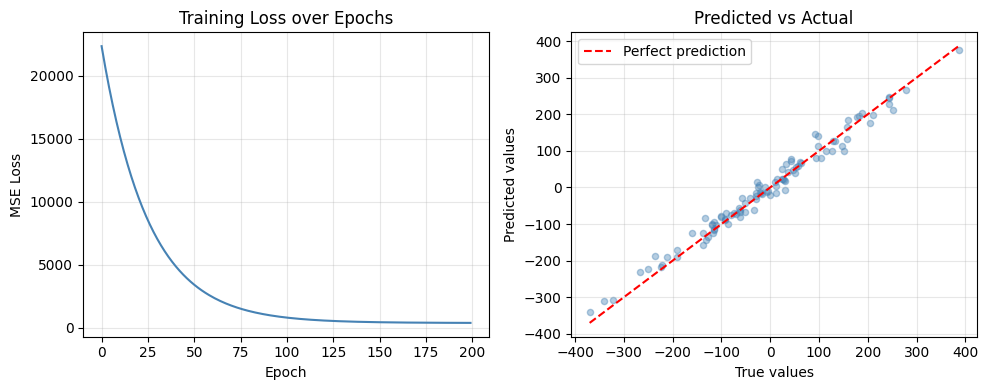

In [ ]:
# ================================================================
# PDF CELL 56: EVALUATION / PLOTS
# Instructor PDF reference: Slide 21. Search the line above to jump here.
# ================================================================
# This cell evaluates the trained PyTorch model and visualises both training progress and prediction quality.

# Matplotlib provides plotting functions for the loss curve and the predicted-versus-actual scatter plot.
import matplotlib.pyplot as plt

# `.eval()` switches the model to evaluation mode; this matters for layers such as dropout or batch normalisation, even though this simple linear model has neither.
model.eval()
# `torch.no_grad()` temporarily disables gradient tracking because evaluation does not require backpropagation and therefore can use less memory.
with torch.no_grad():
    # We run the trained linear model on all 100 test examples.
    y_pred_te = model(X_te)
    # The test MSE is computed and converted from a scalar tensor to a normal Python float.
    pt_mse = loss_fn(y_pred_te, y_te).item()

# We print the scikit-learn test result calculated earlier.
print(f"sklearn  Test MSE : {sk_mse:.2f}")
# We print the PyTorch test result using the same metric.
print(f"PyTorch  Test MSE : {pt_mse:.2f}")
# Because both models are linear and use the same prepared data, their errors should be broadly comparable even though the optimisation procedures differ.
print("(Should be similar — same linear model, same data)")

# This creates one figure that is 10 inches wide and 4 inches tall.
plt.figure(figsize=(10, 4))

# The first subplot occupies position 1 in a 1-row, 2-column layout.
plt.subplot(1, 2, 1)
# We plot the recorded loss values in epoch order; a downward trend indicates that optimisation is reducing the training objective.
plt.plot(loss_history, color='steelblue', linewidth=1.5)
# This title describes the quantity shown in the left panel.
plt.title('Training Loss over Epochs')
# The horizontal axis represents training epochs.
plt.xlabel('Epoch')
# The vertical axis represents mean-squared-error loss.
plt.ylabel('MSE Loss')
# A light grid makes approximate values and trends easier to read.
plt.grid(True, alpha=0.3)

# The second subplot occupies position 2 in the same 1-row, 2-column layout.
plt.subplot(1, 2, 2)
# Each point compares one true target on the x-axis with its PyTorch prediction on the y-axis; points near the diagonal indicate accurate predictions.
plt.scatter(y_te.numpy(), y_pred_te.numpy(), alpha=0.4, color='steelblue', s=20)
# We compute the minimum and maximum true target values to define the endpoints of a reference line.
lim = [y_te.min().item(), y_te.max().item()]
# The line y=x marks perfect predictions, because predicted and true values would be identical at every point on this diagonal.
plt.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect prediction')
# This title describes the comparison shown in the right panel.
plt.title('Predicted vs Actual')
# The horizontal axis contains ground-truth target values.
plt.xlabel('True values')
# The vertical axis contains model predictions.
plt.ylabel('Predicted values')
# The legend explains the meaning of the dashed diagonal reference line.
plt.legend()
# A light grid helps compare scatter points with the axes.
plt.grid(True, alpha=0.3)

# `tight_layout()` automatically adjusts spacing so labels and plots do not overlap.
plt.tight_layout()
# `show()` renders the completed figure in the notebook.
plt.show()


### ✅ What we learnt from this cell

- Evaluation uses `model.eval()` and `torch.no_grad()` because we only need predictions, not gradients.
- The saved test MSE is about **416.37 for scikit-learn** and **439.81 for the PyTorch model**. These are reasonably close but not identical.
- The difference is expected: scikit-learn solves ordinary linear regression directly, whereas our PyTorch version used a finite number of SGD updates from a random initialisation.
- The loss curve tells us whether optimisation is progressing, while the predicted-vs-actual plot tells us how closely predictions follow the ideal `y = x` relationship on unseen data.

In [ ]:
# ================================================================
# PDF CELL 58: DEEPER MODEL
# Instructor PDF reference: Slide 22. Search the line above to jump here.
# ================================================================
# This bonus cell replaces the single linear layer with a small multi-layer neural network to demonstrate a more flexible PyTorch architecture.

# `nn.Sequential(` lets us define a feed-forward network by listing layers in the exact order in which data should pass through them.
deep_model = nn.Sequential(
    # The first linear layer maps the 8 input features into 64 learned hidden features.
    nn.Linear(8, 64),
    # ReLU introduces a non-linear transformation; without non-linearity, stacking linear layers would still behave like one linear transformation.
    nn.ReLU(),
    # The second linear layer compresses the 64 hidden features down to 32.
    nn.Linear(64, 32),
    # A second ReLU adds another non-linear stage.
    nn.ReLU(),
    # The final linear layer maps the 32 hidden features to the single regression output required for each example.
    nn.Linear(32, 1)
# This closing parenthesis finishes the ordered list of layers inside `nn.Sequential`.
)

# Adam is an adaptive gradient-based optimizer; here it will update every trainable parameter in the deeper model using learning rate 0.001.
optimizer = torch.optim.Adam(deep_model.parameters(), lr=0.001)
# We create a new history list so that the deep model's losses are kept separate from the earlier linear model's loss history.
loss_history_deep = []

# `.train()` puts the network in training mode; again, this mainly matters when architectures contain training-sensitive layers such as dropout or batch normalisation.
deep_model.train()
# We perform 300 full training epochs for this neural network.
for epoch in range(300):
    # The forward pass sends all training examples through every layer in the sequential network.
    y_pred = deep_model(X_tr)
    # We reuse the same MSE loss function to compare these predictions with the training targets.
    loss = loss_fn(y_pred, y_tr)
    # Gradients from the previous iteration are cleared before new gradients are calculated.
    optimizer.zero_grad()
    # Backpropagation computes gradients for all weights and biases in all three linear layers.
    loss.backward()
    # Adam uses the new gradients and its running statistics to update the network parameters.
    optimizer.step()
    # We save the scalar loss value from this epoch for possible later inspection or plotting.
    loss_history_deep.append(loss.item())

# After training, we switch the deep model to evaluation mode.
deep_model.eval()
# Evaluation does not need gradients, so we disable gradient tracking to reduce unnecessary computation and memory use.
with torch.no_grad():
    # We generate test predictions and immediately calculate their mean-squared error against the held-out targets.
    deep_mse = loss_fn(deep_model(X_te), y_te).item()

# This line repeats the scikit-learn linear baseline for comparison.
print(f"sklearn linear   MSE : {sk_mse:.2f}")
# This line repeats the PyTorch linear model's test result.
print(f"PyTorch linear   MSE : {pt_mse:.2f}")
# This line reports the deeper neural network's held-out test error.
print(f"PyTorch 3-layer  MSE : {deep_mse:.2f}")
# The message reminds us that deeper networks can represent more complicated functions, although greater expressiveness does not automatically guarantee better test performance.
print("\n🎉 More layers = more expressiveness!")


sklearn linear   MSE : 416.37
PyTorch linear   MSE : 439.83
PyTorch 3-layer  MSE : 1529.96

🎉 More layers = more expressiveness!


### ✅ What we learnt from this cell

- PyTorch makes it easy to replace one linear layer with a deeper non-linear architecture.
- **More expressive does not mean automatically better.** In the saved run, the three-layer model's test MSE is about `1792.38`, much worse than both linear models.
- This synthetic dataset was generated from a linear relationship, so a linear model is already well matched to the underlying problem. A deeper network adds unnecessary flexibility and also has more optimisation choices to tune.
- The correct lesson is therefore: neural networks give us architectural flexibility, but we still need suitable data, optimisation settings, regularisation, and validation before expecting better generalisation.

---
## 🎓 Summary — What you learned

| Concept | Key takeaway |
|---|---|
| **Scalar** | 0-dim tensor, shape `[]`. Loss values are scalars. |
| **Vector** | 1-dim tensor, shape `[N]`. A flat sequence. |
| **Matrix** | 2-dim tensor, shape `[R, C]`. Your dataset. |
| **Tensor** | N-dim array. Images `[B,C,H,W]`, sequences `[B,T,D]`. |
| **`(5,)` vs `(5,1)`** | 1D vs 2D — different broadcast and matmul behaviour. |
| **`unsqueeze/squeeze`** | Add/remove size-1 dimensions. |
| **`view/reshape`** | Reinterpret memory with a new shape. |
| **dtype** | `float32` for weights, `int64` for indices/labels. |
| **device** | `.to(device)` moves tensors to CPU/GPU. |
| **Training loop** | forward → loss → zero_grad → backward → step |